# Predicted wOBA based on Underlying Stats

Created a model to predict wOBA, and another one to predict barrel rate

## Load Packages and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
import sklearn.linear_model as lm

In [3]:
players = pd.read_csv('stats (2).csv')

## Separate Explanatory from Response Variable

In [5]:
X = players.loc[:, ['barrel_batted_rate','avg_swing_speed', 'squared_up_swing', 'z_swing_percent', 'oz_swing_percent', 'whiff_percent', 'hard_hit_percent']] 

In [5]:
y = players['woba']

In [7]:
len(players.columns)

30

## Correlation Matrix of Potential Features to Identify Collinearity

In [8]:
corr_matrix = players.iloc[:,3:30].corr()

In [9]:
corr_matrix.loc[:,"barrel_batted_rate"]

pa                     0.306334
k_percent              0.453213
bb_percent             0.302749
batting_avg            0.104628
slg_percent            0.649627
on_base_percent        0.256576
on_base_plus_slg       0.561484
xba                    0.149332
xslg                   0.798784
woba                   0.522832
xwoba                  0.639091
avg_swing_speed        0.702417
blasts_swing           0.622265
squared_up_swing      -0.365057
attack_angle           0.462655
barrel_batted_rate     1.000000
hard_hit_percent       0.769279
z_swing_percent        0.153629
oz_swing_percent      -0.076732
out_zone_percent       0.327912
iz_contact_percent    -0.480906
in_zone_percent       -0.327912
whiff_percent          0.524706
swing_percent         -0.016855
pull_percent           0.316517
groundballs_percent   -0.389751
flyballs_percent       0.551792
Name: barrel_batted_rate, dtype: float64

## Barrel Rate Model X and y

In [6]:
barrel_model_features = ["avg_swing_speed", "attack_angle", "pull_percent", "flyballs_percent"]

In [7]:
X1 = players.loc[:, ['last_name, first_name', 'player_id', 'year', 'pa', 'k_percent',
       'bb_percent', 'batting_avg', 'slg_percent', 'on_base_percent',
       'on_base_plus_slg', 'xba', 'xslg', 'xwoba', 'avg_swing_speed',
       'blasts_swing', 'squared_up_swing', 'attack_angle', 'barrel_batted_rate',
       'hard_hit_percent', 'z_swing_percent', 'oz_swing_percent',
       'out_zone_percent', 'iz_contact_percent', 'in_zone_percent', 'whiff_percent',
       'swing_percent','pull_percent',
       'groundballs_percent', 'flyballs_percent']]

In [8]:
X2 = players.loc[:, ['last_name, first_name', 'player_id', 'year', 'pa', 'k_percent',
       'bb_percent', 'batting_avg', 'slg_percent', 'on_base_percent',
       'on_base_plus_slg', 'xba', 'xslg', 'xwoba', 'avg_swing_speed',
       'blasts_swing', 'squared_up_swing', 'attack_angle',
       'hard_hit_percent', 'z_swing_percent', 'oz_swing_percent',
       'out_zone_percent', 'iz_contact_percent', 'in_zone_percent', 'whiff_percent',
       'swing_percent','pull_percent',
       'groundballs_percent', 'flyballs_percent']]

In [9]:
y2 = players['barrel_batted_rate']

## Train/Test Set & Create Different Combos of Features

In [10]:
X_train1, X_holdout1, Y_train1, Y_holdout1 = train_test_split(X1, y, test_size =0.20)

In [11]:
X_train2, X_holdout2, Y_train2, Y_holdout2 = train_test_split(X2, y2, test_size =0.20)

In [12]:
def rmse(actual_y, predicted_y):
    return np.sqrt(np.mean((actual_y-predicted_y)**2))

In [13]:
model_options = []

In [14]:
model_options.append(['barrel_batted_rate','avg_swing_speed', 'squared_up_swing', 'z_swing_percent', 'oz_swing_percent', 'whiff_percent', 'hard_hit_percent', 'attack_angle', 'iz_contact_percent', 'flyballs_percent'])

In [15]:
model_options.append(['barrel_batted_rate', 'blasts_swing'])

In [16]:
model_options.append(['barrel_batted_rate', 'squared_up_swing', 'z_swing_percent', 'oz_swing_percent', 'whiff_percent'])

In [17]:
model_options.append(['avg_swing_speed', 'squared_up_swing', 'z_swing_percent', 'oz_swing_percent', 'whiff_percent', 'hard_hit_percent', 'attack_angle'])

In [18]:
model_options

[['barrel_batted_rate',
  'avg_swing_speed',
  'squared_up_swing',
  'z_swing_percent',
  'oz_swing_percent',
  'whiff_percent',
  'hard_hit_percent',
  'attack_angle',
  'iz_contact_percent',
  'flyballs_percent'],
 ['barrel_batted_rate', 'blasts_swing'],
 ['barrel_batted_rate',
  'squared_up_swing',
  'z_swing_percent',
  'oz_swing_percent',
  'whiff_percent'],
 ['avg_swing_speed',
  'squared_up_swing',
  'z_swing_percent',
  'oz_swing_percent',
  'whiff_percent',
  'hard_hit_percent',
  'attack_angle']]

## K fold Cross-Validation on Training Set RMSE - Conducted for Each Model Option

In [19]:
from sklearn.model_selection import KFold
def compute_CV_error_thesefeatures(model, features, X_train, Y_train):
    '''
    Split the training data into 4 subsets.
    For each subset,
    fit a model holding out that subset
    compute the MSE on that subset (the validation set)
    You should be fitting 4 models total.
    Return the average MSE of these 4 folds.
    Args:
    model: an sklearn model with fit and predict functions
    X_train (data_frame): Training data
    Y_train (data_frame): Label
    Return:
    the average validation MSE for the 4 splits.
    '''
    kf = KFold(n_splits=4)
    train_errors = []
    validation_errors = []
    X_train = X_train.loc[:,features]
    for train_idx, valid_idx in kf.split(X_train):
        split_X_train, split_X_valid = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        split_Y_train, split_Y_valid = Y_train.iloc[train_idx], Y_train.iloc[valid_idx]
        # Fit the model on the training split
        model.fit(split_X_train,split_Y_train)

        train_error = rmse(split_Y_train, model.predict(split_X_train))
        train_errors.append(train_error)
        # Compute the RMSE on the validation split
        error = rmse(split_Y_valid, model.predict(split_X_valid))
        validation_errors.append(error)
    return [np.mean(train_errors), np.mean(validation_errors)]

In [20]:
cv_errors_vs_whichFeatures = pd.DataFrame(columns = ["Features", "Training Error", "CV Error"])
for i in range(0,4):
    cv_error = compute_CV_error_thesefeatures(model = lm.LinearRegression(), features = model_options[i], X_train = X_train1, Y_train = Y_train1)
    cv_errors_vs_whichFeatures.loc[len(cv_errors_vs_whichFeatures)] = [model_options[i], cv_error[0], cv_error[1]]

In [21]:
cv_errors_vs_whichFeatures

,Features,Training Error,CV Error
0,"[barrel_batted_rate, avg_swing_speed, squared_...",0.028218,0.029248
1,"[barrel_batted_rate, blasts_swing]",0.031888,0.032358
2,"[barrel_batted_rate, squared_up_swing, z_swing...",0.028791,0.029258
3,"[avg_swing_speed, squared_up_swing, z_swing_pe...",0.030326,0.031528


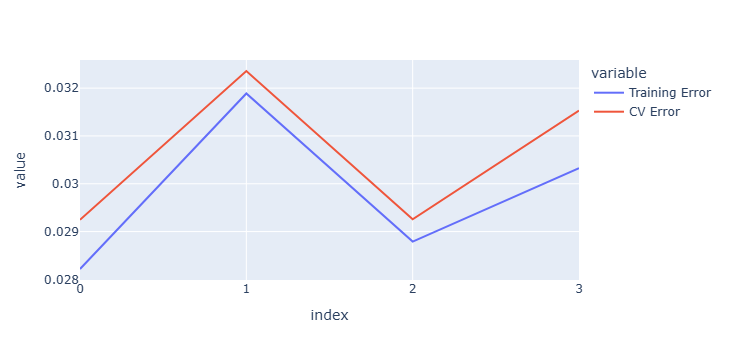

In [23]:
import plotly.express as px
fig = px.line(cv_errors_vs_whichFeatures, x = cv_errors_vs_whichFeatures.index, y = ["Training Error", "CV Error"])
fig.update_xaxes(type='category')
fig.show()

## Calculate RMSE and Holdout Error for Each Model

In [18]:
model1= lm.LinearRegression(fit_intercept=False)
X_train_model1 = X_train1.loc[:,model_options[0]]
X_holdout_model1 = X_holdout1.loc[:,model_options[0]]
model1.fit(X_train_model1, Y_train1)
train_error1 = rmse(Y_train1, model1.predict(X_train_model1))
holdout_error1 = rmse(Y_holdout1, model1.predict(X_holdout_model1))

In [19]:
model2= lm.LinearRegression()
X_train_model2 = X_train1.loc[:,model_options[2]]
X_holdout_model2 = X_holdout1.loc[:,model_options[2]]
model2.fit(X_train_model2, Y_train1)
train_error2 = rmse(Y_train1, model2.predict(X_train_model2))
holdout_error2 = rmse(Y_holdout1, model2.predict(X_holdout_model2))

In [20]:
barrelmodel= lm.LinearRegression(fit_intercept=False)
X_train_model3 = X_train2.loc[:,barrel_model_features]
X_holdout_model3 = X_holdout2.loc[:,barrel_model_features]
barrelmodel.fit(X_train_model3, Y_train2)
train_error3 = rmse(Y_train2, barrelmodel.predict(X_train_model3))
holdout_error3 = rmse(Y_holdout2, barrelmodel.predict(X_holdout_model3))

In [21]:
train_error1

np.float64(0.028489147064140952)

In [22]:
holdout_error1

np.float64(0.03237151889637714)

In [23]:
train_error2

np.float64(0.02883248460125388)

In [24]:
holdout_error2

np.float64(0.03106951489328501)

In [25]:
train_error3

np.float64(3.5940540137962502)

In [26]:
holdout_error3

np.float64(3.5928131528757774)

## Finalize Set of wOBA predictions for players using Model 1

In [30]:
preds= model1.predict(X1.loc[:,model_options[0]])
actuals = y

In [31]:
residuals = preds-actuals

In [32]:
np.mean(residuals)

np.float64(-0.00033287833581550127)

In [33]:
chosen_model = pd.DataFrame(list(zip(X1['last_name, first_name'].tolist(), preds, actuals, residuals)), columns=['Player', 'Predictions', 'Actuals', 'Residuals'])

## Table of Actual vs Predicted 

In [34]:
chosen_model

,Player,Predictions,Actuals,Residuals
0,"Greene, Riley",0.344074,0.343,0.001074
1,"Clase, Jonatan",0.280315,0.267,0.013315
2,"Varsho, Daulton",0.344111,0.345,-0.000889
3,"Guerrero Jr., Vladimir",0.353885,0.366,-0.012115
4,"Refsnyder, Rob",0.347350,0.359,-0.011650
...,...,...,...,...
456,"Stott, Bryson",0.298496,0.315,-0.016504
457,"Roden, Alan",0.250097,0.249,0.001097
458,"Lowe, Josh",0.286070,0.284,0.002070
459,"Vázquez, Christian",0.291626,0.248,0.043626


## Download Model Coefficients (wOBA and Barrle Rate Models) , and Model Selection Data

In [30]:
model_meta = pd.DataFrame(columns = model_options[0])

In [31]:
model_meta.loc[len(model_meta)] = model1.coef_

In [33]:
model_meta

,barrel_batted_rate,avg_swing_speed,squared_up_swing,z_swing_percent,oz_swing_percent,whiff_percent,hard_hit_percent,attack_angle,iz_contact_percent,flyballs_percent
0,0.00476,0.001328,0.001963,0.001213,-0.00101,-0.001802,0.001033,-0.000071,0.00074,0.000447


In [34]:
barrel_model_meta = pd.DataFrame(columns = barrel_model_features)

In [35]:
barrel_model_meta.loc[len(barrel_model_meta)] = barrelmodel.coef_

In [43]:
chosen_model.to_csv("/home/jovyan/predictions_data.csv", index = False)

In [42]:
import os

# Get current working directory
cwd = os.getcwd()
print("Current Working Directory:", cwd)

Current Working Directory: /home/jovyan


In [36]:
model_meta.to_csv("/home/jovyan/modelmetadata2.csv", index = False)

In [37]:
barrel_model_meta.to_csv("/home/jovyan/barrelmodelmetadata.csv", index = False)

In [24]:
cv_errors_vs_whichFeatures.to_csv("/home/jovyan/modelselect.csv", index = False)